<a href="https://colab.research.google.com/github/Ayush-thakur-01/Ml/blob/main/assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
url = "https://media.geeksforgeeks.org/wp-content/uploads/20250303132330481308/synthetic_text_data.csv"

df = pd.read_csv(url)

print(df.head())
print(df.shape)
print(df.columns)

                                                text          label
0  Artificial intelligence is advancing in health...     Technology
1  Football fans are excited about the upcoming W...         Sports
2  New policies regarding climate change have spa...       Politics
3  The latest blockbuster movie has shattered box...  Entertainment
4  Quantum computing promises to revolutionize in...     Technology
(85, 2)
Index(['text', 'label'], dtype='object')


In [ ]:
print(df.isnull().sum())
print(df.dtypes)

text     0
label    0
dtype: int64
text     object
label    object
dtype: object


In [ ]:
df.columns
X = df["text"]
y = df["label"]

print(X.head())
print(y.head())

0    Artificial intelligence is advancing in health...
1    Football fans are excited about the upcoming W...
2    New policies regarding climate change have spa...
3    The latest blockbuster movie has shattered box...
4    Quantum computing promises to revolutionize in...
Name: text, dtype: object
0       Technology
1           Sports
2         Politics
3    Entertainment
4       Technology
Name: label, dtype: object


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(68,) (17,)


In [ ]:
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(X_train_vec.shape)

(68, 395)


In [ ]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

In [ ]:
pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8823529411764706


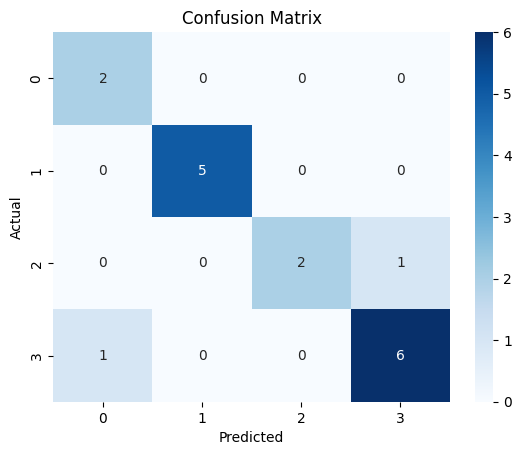

In [ ]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
text = ["This product is excellent and amazing"]

text_vec = vectorizer.transform(text)
print("Prediction:", model.predict(text_vec)[0])

Prediction: Entertainment
